In [10]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname('.'), '..'))
from itertools import combinations, islice

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from gurobipy import GRB, Model, quicksum
from scipy.cluster.hierarchy import dendrogram, linkage

from utils.network import calc_path_similarity, load_network

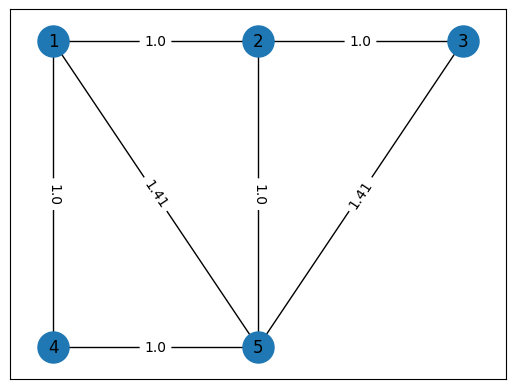

In [11]:
def difine_test_graph(draw: bool=False) -> nx.DiGraph:
    # ノードの座標の定義
    node_positions = {
        1: (0, 1),
        2: (1, 1),
        3: (2, 1),
        4: (0, 0),
        5: (1, 0)
    }

    # エッジの定義
    edges = [
        (1, 2), (1, 4), (1, 5),
        (2, 3), (2, 5), (3, 5),
        (4, 5)
    ]

    # グラフの構築
    graph = nx.Graph()
    graph.add_nodes_from(node_positions.keys())
    graph.add_edges_from(edges)

    # エッジの重み（ユークリッド距離）の計算
    for (u, v) in graph.edges():
        x1, y1 = node_positions[u]
        x2, y2 = node_positions[v]
        distance = np.hypot(x2 - x1, y2 - y1)
        graph.edges[u, v]['weight'] = distance
    # グラフの描画
    if draw:
        edge_labels = nx.get_edge_attributes(graph, 'weight')
        for key, value in edge_labels.items():
            edge_labels[key] = round(value, 2)
        nx.draw_networkx(graph, node_positions, with_labels=True, node_size=500)
        nx.draw_networkx_edge_labels(graph, node_positions, edge_labels=edge_labels)
    # 双方向グラフ化
    graph = graph.to_directed()

    return graph

test_graph = difine_test_graph(draw=True)

Number of nodes: 12
Number of edges: 34


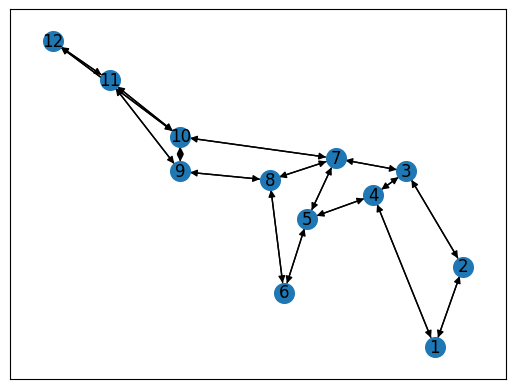

In [13]:
# JPN12の読み込み
jpn12 = load_network('JPN12')
print(f"Number of nodes: {jpn12.number_of_nodes()}")
print(f"Number of edges: {jpn12.number_of_edges()}")
layout = nx.planar_layout(jpn12)
node_positions = {
    1: [6253.2, -5442.6], 
    2: [6716.4, -4014.4], 
    3: [5790., -2316.], 
    4: [5249.6, -2740.6], 
    5: [4168.8, -3165.2], 
    6: [3782.8, -4477.6], 
    7: [4632. , -2084.4], 
    8: [3551.2, -2470.4], 
    9: [2084.4, -2316. ], 
    10: [2084.4, -1698.4], 
    11: [926.4, -694.8], 
    12: [0., 0.]
    }
nx.draw_networkx(jpn12, pos=node_positions, node_size=200)

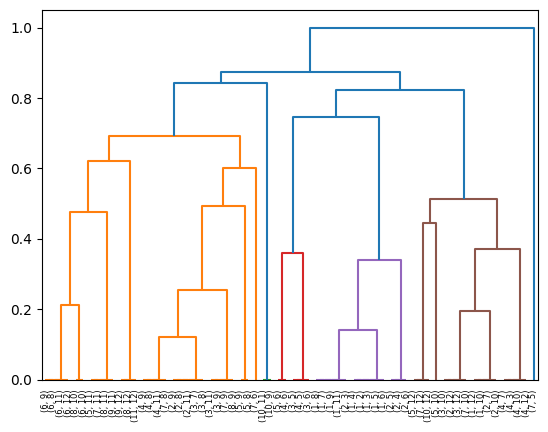

In [12]:
def node_pair_clustering(
    graph: nx.DiGraph, 
    ref_num_paths: int, 
    max_clust: int
    ) -> dict[int, list[tuple[int, int]]]:
    """
    グラフの全ノードペアに対してクラスタリングを行う．クラスタリングの際は，k本の最短経路の類似度を用いる．

    Args:
        graph (nx.DiGraph): グラフ
        k (int): 最短経路の数

    Returns:
        dict[int, list[tuple[int, int]]]: クラスタリング結果
    """
    # 全ノードペアを生成
    node_pairs = list(combinations(graph.nodes(), 2))

    # 各ノードペアに対してk本の最短経路を計算
    node_pair_paths = {}
    for u, v in node_pairs:
        try:
            paths = list(islice(nx.shortest_simple_paths(graph, u, v, weight='weight'), ref_num_paths))
            node_pair_paths[(u, v)] = paths
        except nx.NetworkXNoPath:
            pass  # パスが存在しない場合はスキップ

    # ノードペアのリストを取得
    node_pair_list = list(node_pair_paths.keys())
    n = len(node_pair_list)

    # 距離行列（凝縮された形式）を作成
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            paths1 = node_pair_paths[node_pair_list[i]]
            paths2 = node_pair_paths[node_pair_list[j]]
            sim = calc_node_pair_similarity(graph, paths1, paths2, edge_weight='physical-length')
            distance = 1 - sim  # 類似度から距離に変換
            distances.append(distance)

    # 階層型クラスタリングを実行
    linked = linkage(distances, method='average')

    # デンドログラムをプロット
    labelList = [str(pair) for pair in node_pair_list]

    dendrogram(linked,
               labels=labelList,
               distance_sort='descending',
               show_leaf_counts=True)
    plt.show()

    # クラスタリング結果を返す（クラスタ数は任意で設定可能）
    from scipy.cluster.hierarchy import fcluster
    max_clusters = max_clust  # 例としてクラスタ数を5に設定
    cluster_assignments = fcluster(linked, t=max_clusters, criterion='maxclust')

    # クラスタリング結果を辞書にまとめる
    clustering_result = {}
    for idx, cluster_id in enumerate(cluster_assignments):
        pair = node_pair_list[idx]
        if cluster_id not in clustering_result:
            clustering_result[cluster_id] = []
        clustering_result[cluster_id].append(pair)

    return clustering_result


def calc_node_pair_similarity(
    graph: nx.DiGraph,
    paths1: list[list[int]],
    paths2: list[list[int]],
    edge_weight: str = 'physical-length'
    ) -> float:
    """
    2つのノードペアの類似度を計算する

    Args:
        graph (nx.DiGraph): グラフ
        paths1 (list[list[int]]): ノードペア1のパスリスト
        paths2 (list[list[int]]): ノードペア2のパスリスト
        edge_weight (str): エッジの重みの種類

    Returns:
        float: 類似度
    """
    sim = 0
    for path1 in paths1:
        for path2 in paths2:
            sim = calc_path_similarity(graph, path1, path2, edge_weight=edge_weight)

    return sim


clusters = node_pair_clustering(jpn12, 1, 6)

In [5]:
# # 頂点対のクラスタの定義
# cluster_1_pairs = [(1, 2), (2, 3), (1, 3)]
# cluster_2_pairs = [pair for pair in combinations(jpn12.nodes(), 2) if pair not in cluster_1_pairs]
# clusters = {
#     1: cluster_1_pairs,
#     2: cluster_2_pairs
# }

# クラスタの逆引き（頂点対からクラスタへのマッピング）
pair_to_cluster = {}
for c in clusters:
    for u, v in clusters[c]:
        pair_to_cluster[(u, v)] = c
        pair_to_cluster[(v, u)] = c

In [6]:
# 全ての頂点対のリスト
all_node_pairs = list(combinations(jpn12.nodes(), 2))

# 各頂点対に対して最短パスと候補パスを生成
shortest_paths = {}
candidate_paths = {}
path_index = 0
path_indices = {}
for u, v in all_node_pairs:
    # 最短パスの計算
    shortest_path = nx.dijkstra_path(jpn12, u, v, weight='weight')
    shortest_paths[(u, v)] = shortest_path

    # 全ての単純パスを生成（cutoff を設定して計算量を削減）
    all_simple_paths = list(nx.all_simple_paths(jpn12, u, v))
    # 最短パスを除いたパスを候補パスとする
    candidate_paths_uv = [p for p in all_simple_paths if p != shortest_path]
    candidate_paths[(u, v)] = candidate_paths_uv

    # パスにインデックスを付与
    for p in candidate_paths_uv:
        p_tuple = tuple(p)
        if p_tuple not in path_indices:
            path_indices[p_tuple] = path_index
            path_index += 1

In [7]:
def solve_optimization_problem(graph, k, alpha):
    # 変数の定義
    model = Model("Path_Selection_Problem")
    
    # x_{uvp} の定義
    x_vars = {}
    for u, v in all_node_pairs:
        for p in candidate_paths[(u, v)]:
            p_tuple = tuple(p)
            var_name = f"x_{u}_{v}_{path_indices[p_tuple]}"
            x_vars[(u, v, p_tuple)] = model.addVar(vtype=GRB.BINARY, name=var_name)
    
    # z_{ce} の定義
    z_vars = {}
    for c in clusters:
        for e in graph.edges():
            var_name = f"z_{c}_{e[0]}_{e[1]}"
            z_vars[(c, e)] = model.addVar(vtype=GRB.BINARY, name=var_name)
    
    model.update()
    
    # パスの長さの比率 r_{uvp} の計算
    r = {}
    for u, v in all_node_pairs:
        shortest_length = nx.dijkstra_path_length(graph, u, v, weight='weight')
        for p in candidate_paths[(u, v)]:
            p_length = sum(graph.edges[p[i], p[i+1]]['weight'] for i in range(len(p)-1))
            r[(u, v, tuple(p))] = p_length / shortest_length
    
    # 目的関数の定義
    model.setObjective(
        quicksum(alpha * r[(u, v, p_tuple)] * x_vars[(u, v, p_tuple)]
                 for u, v in all_node_pairs
                 for p_tuple in [tuple(p) for p in candidate_paths[(u, v)]]) +
        quicksum((1 - alpha) * z_vars[(c, e)]
                 for c in clusters
                 for e in graph.edges()),
        GRB.MINIMIZE
    )
    
    # 制約条件 1：全ての頂点対で (k - 1) 本のパスを選択
    model.addConstr(
        quicksum(
            x_vars[(u, v, tuple(p))] 
            for u, v in all_node_pairs
            for p in candidate_paths[(u, v)]
            ) == (k - 1) * len(all_node_pairs),  
        name="constraint_k"
    )
    
    # 制約条件 2：エッジ使用とクラスタ内リンク共有の関係
    for u, v in all_node_pairs:
        c = pair_to_cluster[(u, v)]
        for p in candidate_paths[(u, v)]:
            p_edges = [(p[i], p[i+1]) if (p[i], p[i+1]) in graph.edges() else (p[i+1], p[i]) for i in range(len(p)-1)]
            for e in p_edges:
                model.addConstr(
                    x_vars[(u, v, tuple(p))] <= z_vars[(c, e)],
                    name=f"edge_usage_{u}_{v}_{path_indices[tuple(p)]}_{e}"
                )
    
    # 問題の解決
    model.optimize()
    
    # 選択されたパスを格納
    selected_paths = {}
    for u, v in all_node_pairs:
        selected_paths[(u, v)] = []
        for p in candidate_paths[(u, v)]:
            p_tuple = tuple(p)
            var = x_vars[(u, v, p_tuple)]
            if var.X > 0.5:
                selected_paths[(u, v)].append(p)
        # 最短パスを追加
        selected_paths[(u, v)].insert(0, shortest_paths[(u, v)])
    
    return selected_paths

In [8]:
k = 2
# 各頂点対で k-最短パスを計算（k の値に基づく）
k_shortest_paths = {}
for u, v in all_node_pairs:
    # Yen のアルゴリズムを使用
    paths_generator = list(nx.shortest_simple_paths(jpn12, u, v, weight='weight'))
    k_shortest_paths[(u, v)] = paths_generator[:k]

  0%|          | 0/3 [00:00<?, ?it/s]

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7645 rows, 1306 columns and 16390 nonzeros
Model fingerprint: 0xc570f3d8
Variable types: 0 continuous, 1306 integer (1306 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [7e+01, 7e+01]
Found heuristic solution: objective 108.0000000
Presolve removed 425 rows and 75 columns
Presolve time: 0.04s
Presolved: 7220 rows, 1231 columns, 15540 nonzeros
Variable types: 0 continuous, 1231 integer (1231 binary)
Found heuristic solution: objective 103.0000000

Root relaxation: objective 4.562212e+00, 2555 iterations, 0.07 seconds (0.19 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

  0%|          | 0/3 [00:02<?, ?it/s]


NetworkXError: Node 7 has no position.

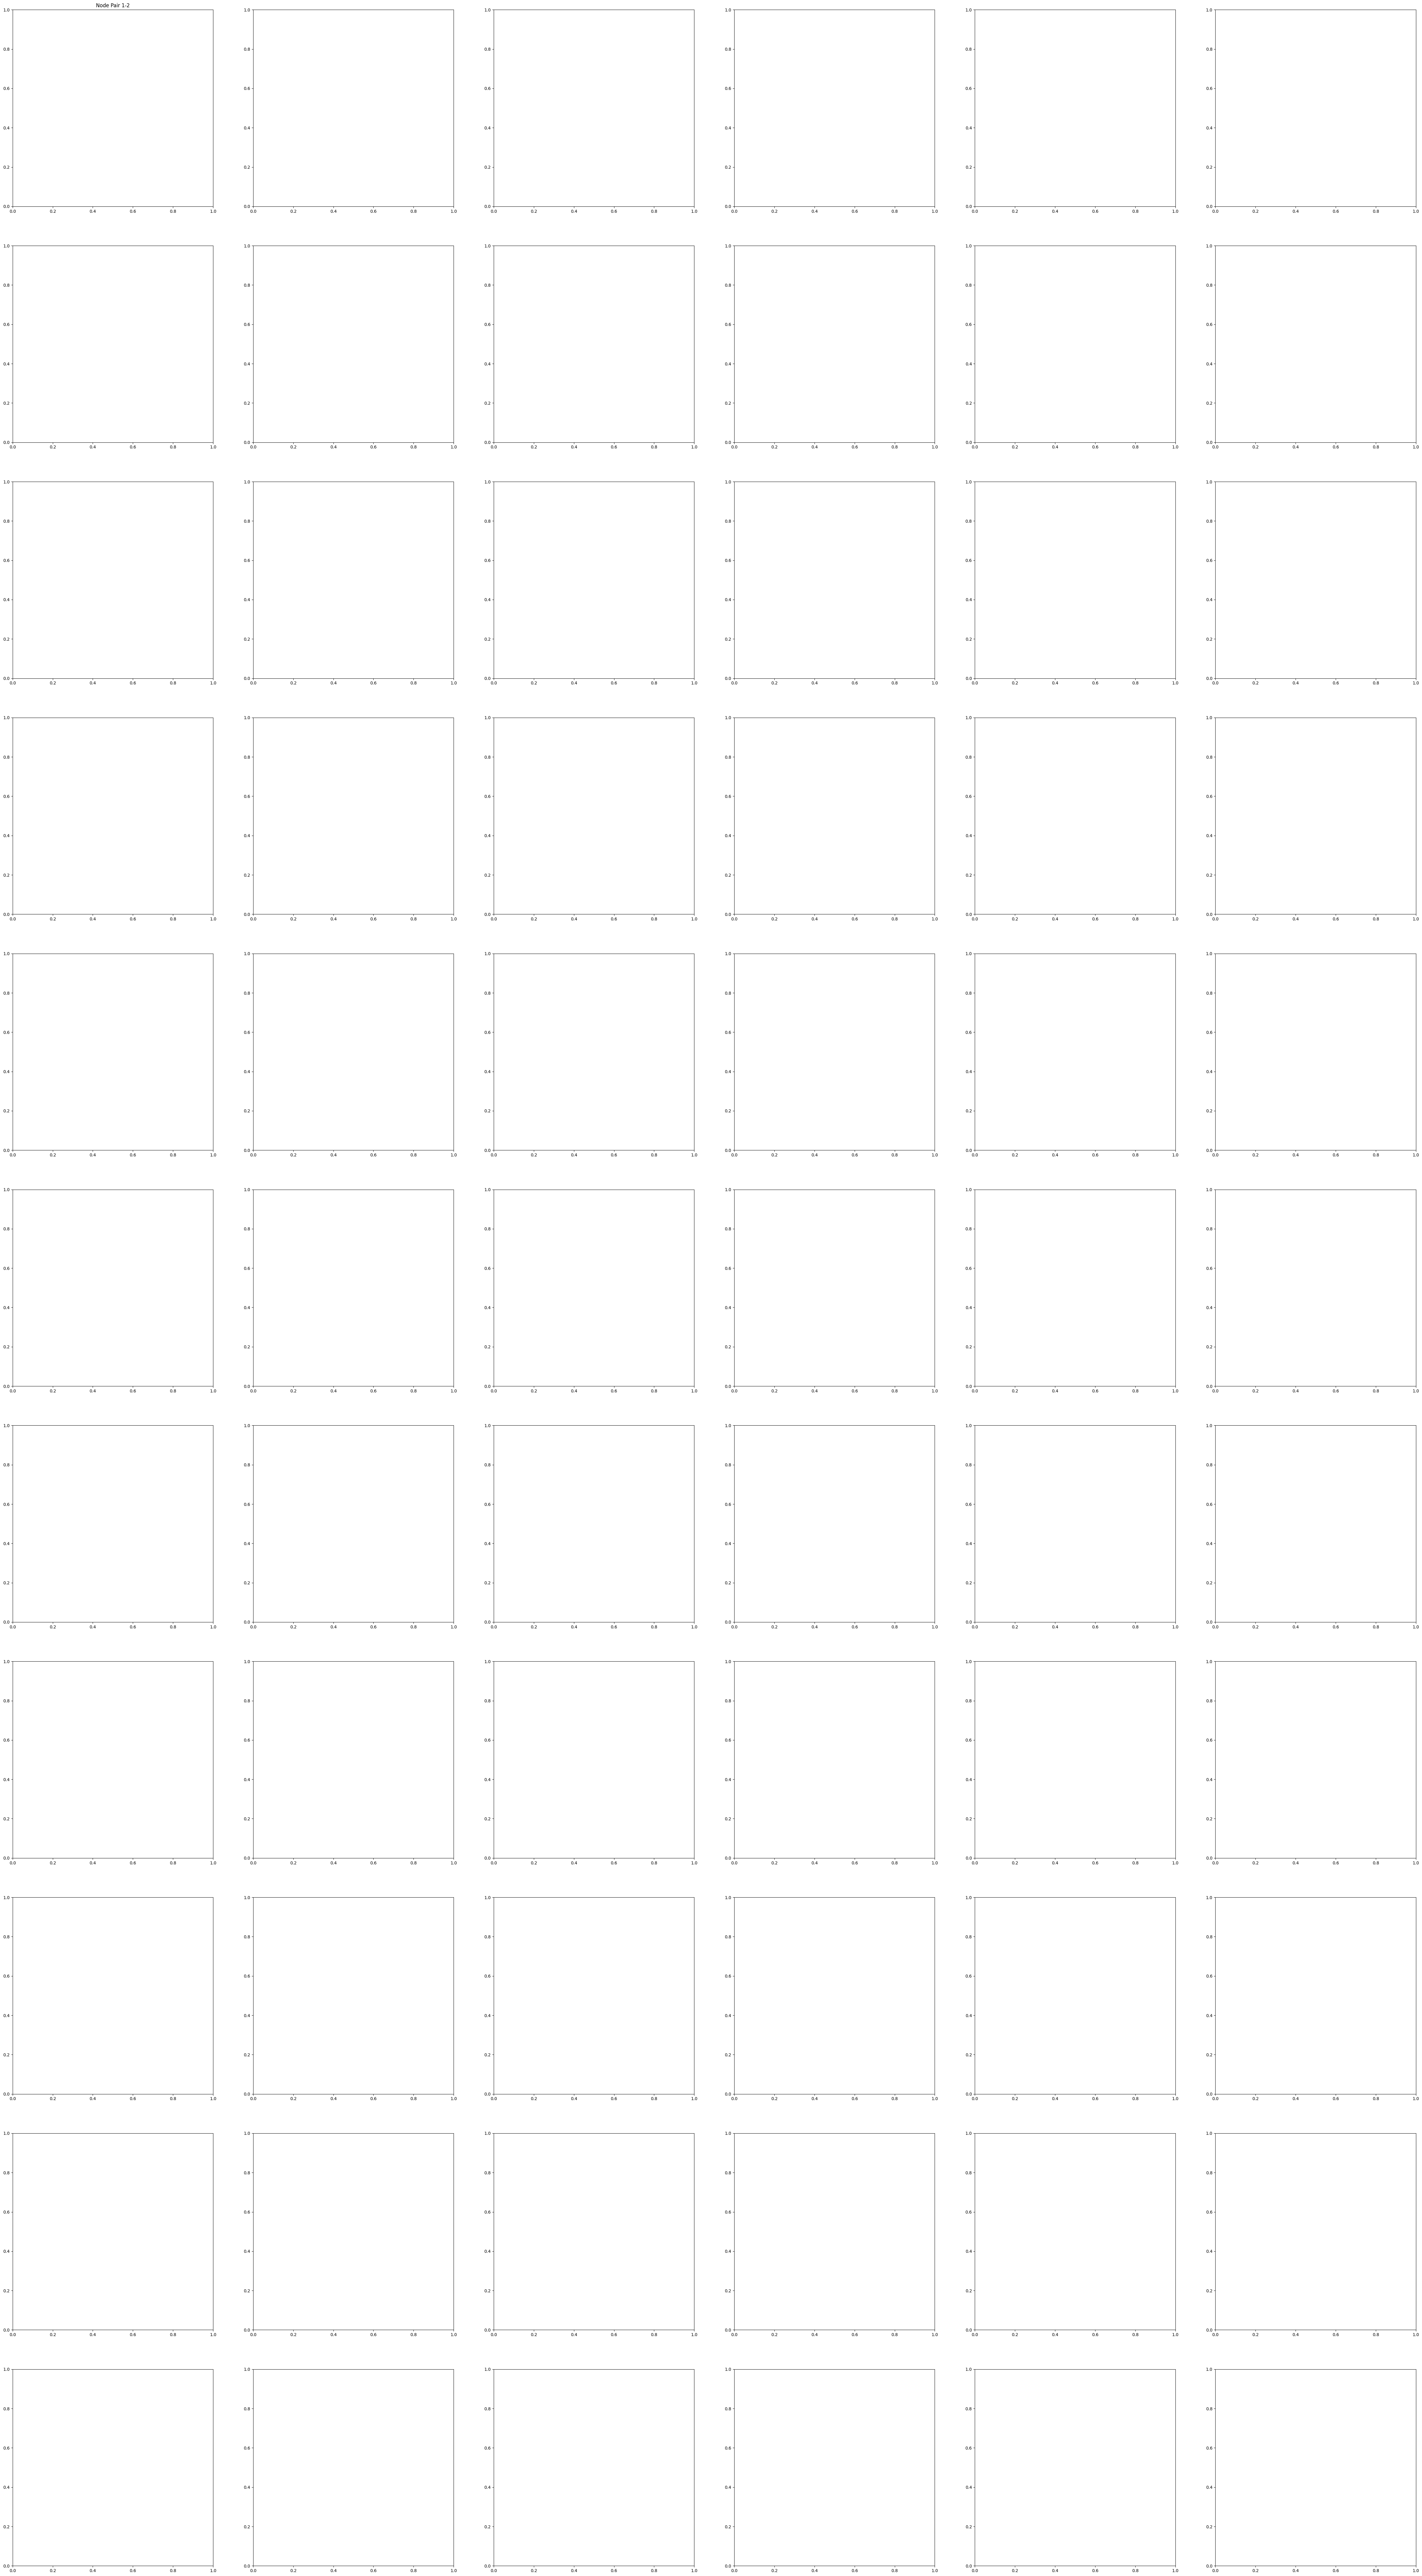

In [10]:
def visualize_paths(graph, paths_dict, title):
    fig, axes = plt.subplots(11, 6, figsize=(60, 110))
    axes = axes.flatten()
    
    for idx, (u, v) in enumerate(all_node_pairs):
        ax = axes[idx]
        ax.set_title(f"Node Pair {u}-{v}")
        pos = node_positions

        # ノードの描画
        nx.draw_networkx_nodes(graph, pos, ax=ax, node_color='lightblue', node_size=500)

        # エッジの描画
        nx.draw_networkx_edges(graph, pos, ax=ax, edge_color='gray')

        # パスの描画
        colors = ['red', 'green', 'blue', 'orange', 'purple']
        for i, path in enumerate(paths_dict[(u, v)]):
            edge_list = [(path[j], path[j+1]) for j in range(len(path)-1)]
            nx.draw_networkx_edges(graph, pos, edgelist=edge_list, ax=ax,
                                   edge_color=colors[i % len(colors)], width=4, style='solid')

        # ノードラベルの描画
        nx.draw_networkx_labels(graph, pos, ax=ax, font_size=12, font_color='black')

        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

import tqdm

for alpha in tqdm.tqdm([0.0, 0.5, 1.0]):
    selected_paths = solve_optimization_problem(jpn12, k, alpha)
    print(selected_paths)
    # 選択されたパスの可視化
    visualize_paths(jpn12, selected_paths, title=f"Selected Paths (alpha={alpha})")

# k-最短パスの可視化
visualize_paths(jpn12, k_shortest_paths, title='k-Shortest Paths')